# Image Threshold Tuning

Runs a grid search over a stratified subsample of the PDF dataset to find the
optimal detection-confidence threshold for the newspaper-navigator model.
Validation is at **page level per content type** (TP/FP/TN/FN for each class).
Recall is preferred over precision to minimise false negatives.
Refactored from `img_extractor.ipynb`.

Setup:
1. Ensure all scripts in `labeling/` have been run.
2. Upload `labels.csv` (output of `review_labels.py`) to Google Drive.
3. Open in Colab, mount Drive, run all cells.

### Dependencies

In [1]:
import subprocess, sys
from pathlib import Path

def sh(cmd): subprocess.run(cmd, shell=True, check=True)

sh("apt-get install -qq -y poppler-utils")
sh(f"{sys.executable} -m pip install -q requests beautifulsoup4 tqdm "
   "pdf2image opencv-python-headless pillow layoutparser "
   "ipywidgets faiss-cpu transformers scikit-learn joblib matplotlib seaborn")

try:
    import torch
except ImportError:
    sh(f"{sys.executable} -m pip install -q torch torchvision")

import torch
torch_ver = torch.__version__.split("+")[0]
cuda_tag  = ("cu" + torch.version.cuda.replace(".", "")) if torch.cuda.is_available() else "cpu"
print(f"torch {torch_ver} | {cuda_tag}")

try:
    import detectron2
except ImportError:
    wheel_index = (f"https://dl.fbaipublicfiles.com/detectron2/wheels/"
                   f"{cuda_tag}/torch{torch_ver}/index.html")
    result = subprocess.run(
        f"{sys.executable} -m pip install -q detectron2 -f {wheel_index}", shell=True)
    if result.returncode != 0:
        sh(f"{sys.executable} -m pip install -q --no-build-isolation "
           "'git+https://github.com/facebookresearch/detectron2.git'")

# download newspaper-navigator weights if not present
weights_path = Path.home() / "newspaper_navigator_model" / "model_final.pth"
weights_path.parent.mkdir(parents=True, exist_ok=True)
if not weights_path.exists():
    sh(f"wget -q -O {weights_path} "
       "https://github.com/LibraryOfCongress/newspaper-navigator/releases/"
       "download/v1.0.0/model_final.pth")
print("weights ready")

torch 2.10.0 | cu128
weights ready


### Mount Drive & Unzip PDFs

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


### Config

In [3]:
import torch
from pathlib import Path

DRIVE_ROOT   = Path("/content/drive/MyDrive/")
PDF_DIR      = Path("/content/drive/Othercomputers/My Laptop/pdfs")
LABELS_CSV   = DRIVE_ROOT / "labels.csv"
OUTPUT_DIR   = DRIVE_ROOT / "gridsearch_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_RATIO    = 0.20
TEST_RATIO   = 0.10
RANDOM_STATE = 42

THRESHOLD_VALUES     = [0.4, 0.5, 0.6, 0.7]
MIN_INFERENCE_THRESH = 0.05   # run model once at this floor; filter in post

WEIGHTS_PATH = Path.home() / "newspaper_navigator_model" / "model_final.pth"
NUM_CLASSES  = 7
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

# classes that count as visual content (not headline/ad)
IMAGE_CLASS_IDS = {0, 1, 2, 3, 4}
LABEL_NAMES     = ["Photograph", "Illustration", "Map",
                   "Comic", "EditorialCartoon", "Headline", "Advertisement"]

# maps model class id -> labels.csv column name
CLASS_COL_MAP = {
    0: "photograph",
    1: "illustration",
    2: "map",
    3: "comic",
    4: "editorial_cartoon",
}

print(f"Device : {DEVICE}")
print(f"Output : {OUTPUT_DIR}")

Device : cuda
Output : /content/drive/MyDrive/gridsearch_results


### Data Loading & Stratified Split

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

labels = pd.read_csv(LABELS_CSV)

# derive per-class binary labels from count columns
for class_id, col in CLASS_COL_MAP.items():
    labels[f"has_{col}"] = (labels[col].fillna(0).astype(int) > 0).astype(int)

# aggregate: positive if any image-class type is present
image_cols = [f"has_{col}" for col in CLASS_COL_MAP.values()]
labels["has_image"] = labels[image_cols].any(axis=1).astype(int)

df = labels.copy()

print(f"Labeled pages  : {len(df)}")
print(f"  with image   : {df['has_image'].sum()}")
print(f"  without      : {(df['has_image']==0).sum()}")
print(f"Years covered  : {sorted(df['year'].unique())}\n")

for class_id, col in CLASS_COL_MAP.items():
    n = df[f"has_{col}"].sum()
    print(f"  {col:20s}: {n} ({n/len(df)*100:.1f}%)")

# stratified split by year
train_parts, val_parts, test_parts = [], [], []
for year, grp in df.groupby("year"):
    if len(grp) < 5:
        train_parts.append(grp)
        continue
    try:
        tr, tmp = train_test_split(grp, test_size=VAL_RATIO + TEST_RATIO,
                                   random_state=RANDOM_STATE, stratify=grp["has_image"])
    except ValueError:
        tr, tmp = train_test_split(grp, test_size=VAL_RATIO + TEST_RATIO,
                                   random_state=RANDOM_STATE)
    rel_test = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
    try:
        v, te = train_test_split(tmp, test_size=rel_test,
                                  random_state=RANDOM_STATE, stratify=tmp["has_image"])
    except ValueError:
        v, te = train_test_split(tmp, test_size=rel_test, random_state=RANDOM_STATE)
    train_parts.append(tr); val_parts.append(v); test_parts.append(te)

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df   = pd.concat(val_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

print(f"\nSplit -> train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")
print(f"Val prevalence (has_image): {val_df['has_image'].mean():.2%}")

Labeled pages  : 416
  with image   : 238
  without      : 178
Years covered  : [np.int64(1902), np.int64(1903), np.int64(1904), np.int64(1905), np.int64(1906), np.int64(1907), np.int64(1908), np.int64(1909), np.int64(1910), np.int64(1911), np.int64(1912), np.int64(1913), np.int64(1914), np.int64(1915), np.int64(1916), np.int64(1917), np.int64(1918), np.int64(1919), np.int64(1920), np.int64(1921), np.int64(1922), np.int64(1923), np.int64(1924), np.int64(1925), np.int64(1926), np.int64(1927), np.int64(1928), np.int64(1929), np.int64(1930), np.int64(1931), np.int64(1932), np.int64(1933), np.int64(1934), np.int64(1935), np.int64(1936), np.int64(1937), np.int64(1938), np.int64(1939), np.int64(1940), np.int64(1941), np.int64(1942), np.int64(1943), np.int64(1944), np.int64(1945), np.int64(1946), np.int64(1947), np.int64(1948), np.int64(1949), np.int64(1950), np.int64(1951), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int6

### Model Setup

In [6]:
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.model_zoo import model_zoo

def build_predictor(score_thresh: float) -> DefaultPredictor:
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(
        "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
    cfg.MODEL.WEIGHTS                     = str(WEIGHTS_PATH)
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = score_thresh
    cfg.MODEL.ROI_HEADS.NUM_CLASSES       = NUM_CLASSES
    cfg.MODEL.DEVICE                      = DEVICE
    cfg.INPUT.MIN_SIZE_TEST               = 800
    cfg.INPUT.MAX_SIZE_TEST               = 1333
    return DefaultPredictor(cfg)

# build at minimum threshold; apply per-class filtering in post
predictor = build_predictor(MIN_INFERENCE_THRESH)
print(f"Predictor ready (min_thresh={MIN_INFERENCE_THRESH}, device={DEVICE})")

Predictor ready (min_thresh=0.05, device=cuda)


### Run Inference

One pass at the minimum threshold; I filter by class and confidence in post.

In [7]:
import json
import numpy as np
from pdf2image import convert_from_path
from tqdm import tqdm


def infer_pdf_pages(archive_path: str, page_nums: list[int]) -> list[dict]:
    """Convert requested pages and run detection. Returns one dict per page."""
    pdf_path = PDF_DIR / archive_path
    results  = []
    for pg in page_nums:
        try:
            imgs = convert_from_path(str(pdf_path), dpi=150,
                                     first_page=pg + 1, last_page=pg + 1)
            arr = np.array(imgs[0])[:, :, ::-1]   # RGB -> BGR for detectron2
            out  = predictor(arr)
            inst = out["instances"].to("cpu")
            results.append({
                "archive_path": archive_path,
                "page_num":     pg,
                "scores":       inst.scores.numpy().tolist(),
                "classes":      inst.pred_classes.numpy().tolist(),
                "boxes":        inst.pred_boxes.tensor.numpy().tolist(),
            })
        except Exception as e:
            print(f"  [WARN] {archive_path} p{pg}: {e}")
            results.append({"archive_path": archive_path, "page_num": pg,
                            "scores": [], "classes": [], "boxes": []})
    return results


# group val pages by PDF to minimize repeated PDF opens
val_grouped = val_df.groupby("archive_path")["page_num"].apply(list)

raw_records = []
for archive_path, pages in tqdm(val_grouped.items(), desc="Inference (val)"):
    raw_records.extend(infer_pdf_pages(archive_path, pages))

raw_df = pd.DataFrame(raw_records)

# save as JSON
out_path = OUTPUT_DIR / "raw_detections_val.json"
raw_df.to_json(out_path, orient="records")
print(f"{len(raw_df)} page records -> raw_detections_val.json")

Inference (val): 0it [00:00, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0426 22:33:19.758000 9659 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
Inference (val): 83it [06:27,  4.67s/it]


83 page records -> raw_detections_val.json


### Parallelized Gridsearch

In [8]:
from joblib import Parallel, delayed


def apply_threshold(threshold: float,
                    raw_df: pd.DataFrame,
                    ground_truth: pd.DataFrame) -> pd.DataFrame:
    """Filter detections at threshold per class, merge with ground truth."""
    rows = []
    for _, det in raw_df.iterrows():
        row = {
            "archive_path": det["archive_path"],
            "page_num":     det["page_num"],
            "threshold":    threshold,
        }
        # per-class prediction; any detection of that class above threshold
        for class_id, col in CLASS_COL_MAP.items():
            row[f"pred_{col}"] = int(any(
                s >= threshold and c == class_id
                for s, c in zip(det["scores"], det["classes"])
            ))
        # aggregate prediction
        row["predicted"] = int(any(
            s >= threshold and c in IMAGE_CLASS_IDS
            for s, c in zip(det["scores"], det["classes"])
        ))
        rows.append(row)

    pred_df = pd.DataFrame(rows)
    gt_cols = ["archive_path", "page_num", "has_image", "year"] + [f"has_{col}" for col in CLASS_COL_MAP.values()]
    merged = pred_df.merge(ground_truth[gt_cols],
                           on=["archive_path", "page_num"], how="inner")
    return merged


results_list = Parallel(n_jobs=-1, verbose=5)(
    delayed(apply_threshold)(t, raw_df, val_df) for t in THRESHOLD_VALUES
)

results_df = pd.concat(results_list).reset_index(drop=True)
results_df.to_csv(OUTPUT_DIR / "threshold_results.csv", index=False)

summary = (
    results_df.groupby("threshold")
    .apply(lambda g: pd.Series({
        "n_pages":     len(g),
        "pred_pos":    g["predicted"].sum(),
        "true_pos_gt": g["has_image"].sum(),
    }))
)
print(summary)
print("\nGridsearch complete -> threshold_results.csv")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


           n_pages  pred_pos  true_pos_gt
threshold                                
0.4             83        47           48
0.5             83        47           48
0.6             83        46           48
0.7             83        42           48

Gridsearch complete -> threshold_results.csv


[Parallel(n_jobs=-1)]: Done   2 out of   4 | elapsed:    0.7s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done   4 out of   4 | elapsed:    0.7s finished
/tmp/ipykernel_9659/1262940718.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


### Evaluation

Per-class TP/FP/TN/FN for each threshold, plus aggregate metrics.


Threshold 0.4
  aggregate -> TP=47 FP=0 TN=35 FN=1 | F1=0.989 Rec=0.979 Prec=1.000
  photograph             -> TP= 42 FP=  0 TN= 40 FN=  1 | F1=0.988 Rec=0.977 Prec=1.000
  illustration           -> TP=  5 FP=  2 TN= 75 FN=  1 | F1=0.769 Rec=0.833 Prec=0.714
  map                    -> TP=  0 FP=  2 TN= 81 FN=  0 | F1=0.000 Rec=0.000 Prec=0.000
  comic                  -> TP=  0 FP=  0 TN= 82 FN=  1 | F1=0.000 Rec=0.000 Prec=0.000
  editorial_cartoon      -> TP=  0 FP=  1 TN= 82 FN=  0 | F1=0.000 Rec=0.000 Prec=0.000

Threshold 0.5
  aggregate -> TP=47 FP=0 TN=35 FN=1 | F1=0.989 Rec=0.979 Prec=1.000
  photograph             -> TP= 42 FP=  0 TN= 40 FN=  1 | F1=0.988 Rec=0.977 Prec=1.000
  illustration           -> TP=  4 FP=  1 TN= 76 FN=  2 | F1=0.727 Rec=0.667 Prec=0.800
  map                    -> TP=  0 FP=  2 TN= 81 FN=  0 | F1=0.000 Rec=0.000 Prec=0.000
  comic                  -> TP=  0 FP=  0 TN= 82 FN=  1 | F1=0.000 Rec=0.000 Prec=0.000
  editorial_cartoon      -> TP=  0 FP=  

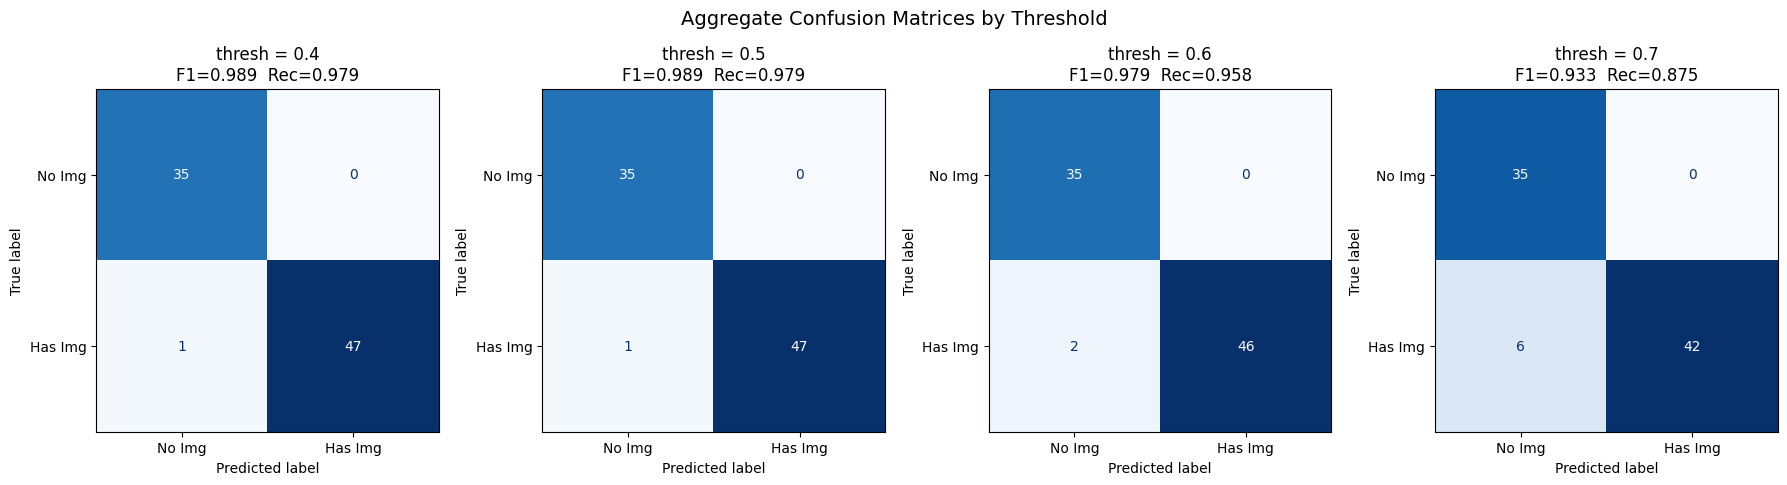

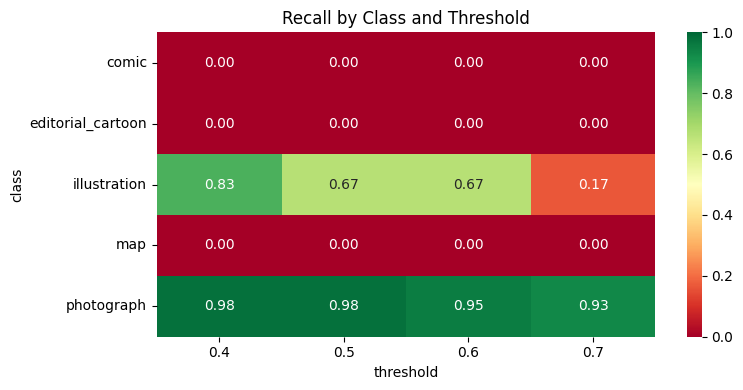

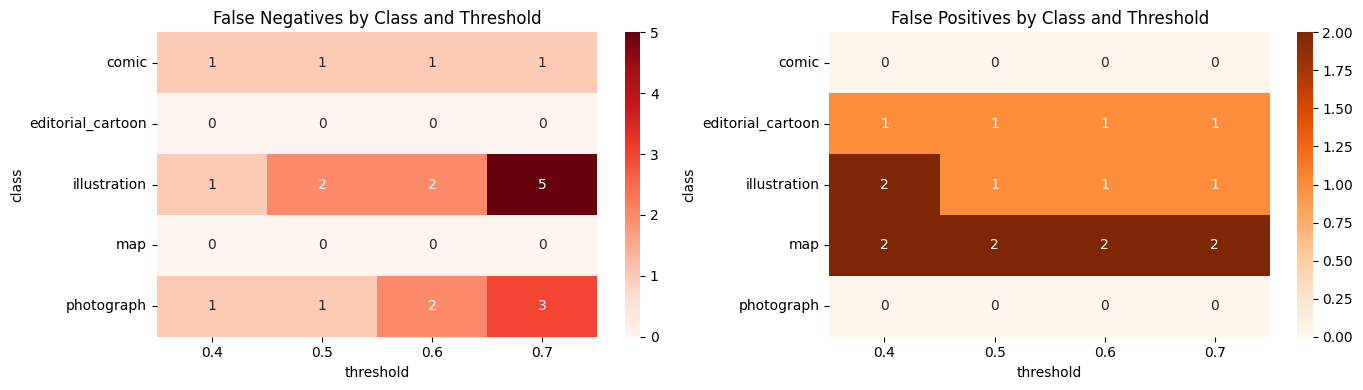

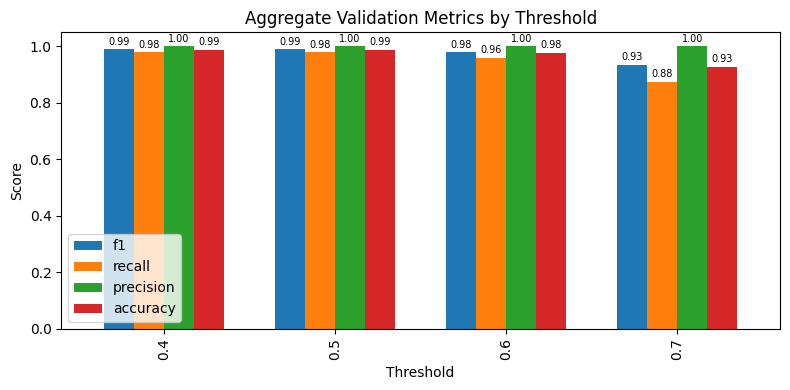

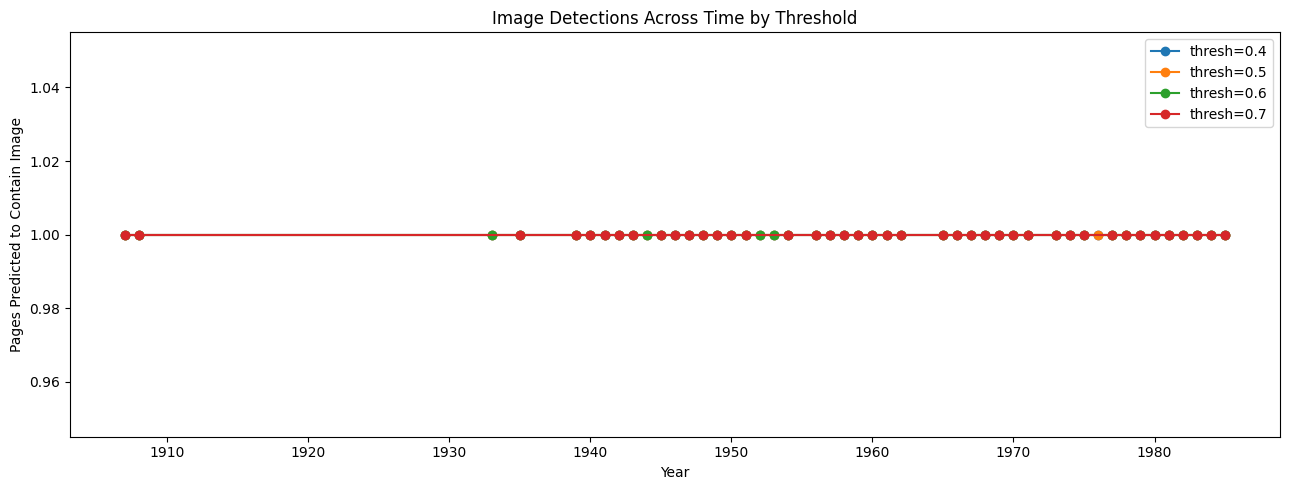


Absolute detections by threshold:
 threshold  total_detected
       0.4              47
       0.5              47
       0.6              46
       0.7              42


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)

all_metric_rows = []

for thresh in THRESHOLD_VALUES:
    sub = results_df[results_df["threshold"] == thresh]
    print(f"\nThreshold {thresh}")

    # aggregate
    y_true, y_pred = sub["has_image"], sub["predicted"]
    agg = {
        "threshold": thresh,
        "class":     "aggregate",
        "accuracy":  accuracy_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "tp": int(((y_pred == 1) & (y_true == 1)).sum()),
        "fp": int(((y_pred == 1) & (y_true == 0)).sum()),
        "tn": int(((y_pred == 0) & (y_true == 0)).sum()),
        "fn": int(((y_pred == 0) & (y_true == 1)).sum()),
    }
    all_metric_rows.append(agg)
    print(f"  aggregate -> TP={agg['tp']} FP={agg['fp']} TN={agg['tn']} FN={agg['fn']} "
          f"| F1={agg['f1']:.3f} Rec={agg['recall']:.3f} Prec={agg['precision']:.3f}")

    # per class
    for class_id, col in CLASS_COL_MAP.items():
        yt = sub[f"has_{col}"]
        yp = sub[f"pred_{col}"]
        row = {
            "threshold": thresh,
            "class":     col,
            "accuracy":  accuracy_score(yt, yp),
            "f1":        f1_score(yt, yp, zero_division=0),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall":    recall_score(yt, yp, zero_division=0),
            "tp": int(((yp == 1) & (yt == 1)).sum()),
            "fp": int(((yp == 1) & (yt == 0)).sum()),
            "tn": int(((yp == 0) & (yt == 0)).sum()),
            "fn": int(((yp == 0) & (yt == 1)).sum()),
        }
        all_metric_rows.append(row)
        print(f"  {col:22s} -> TP={row['tp']:3d} FP={row['fp']:3d} "
              f"TN={row['tn']:3d} FN={row['fn']:3d} "
              f"| F1={row['f1']:.3f} Rec={row['recall']:.3f} Prec={row['precision']:.3f}")

metrics_df = pd.DataFrame(all_metric_rows)
metrics_df.to_csv(OUTPUT_DIR / "metrics_by_threshold.csv", index=False)

agg_metrics = metrics_df[metrics_df["class"] == "aggregate"].set_index("threshold")

# aggregate confusion matrices
fig, axes = plt.subplots(1, len(THRESHOLD_VALUES),
                         figsize=(4.5 * len(THRESHOLD_VALUES), 4.5))
for ax, thresh in zip(axes, THRESHOLD_VALUES):
    sub = results_df[results_df["threshold"] == thresh]
    cm  = confusion_matrix(sub["has_image"], sub["predicted"])
    ConfusionMatrixDisplay(cm, display_labels=["No Img", "Has Img"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    row = agg_metrics.loc[thresh]
    ax.set_title(f"thresh = {thresh}\nF1={row['f1']:.3f}  Rec={row['recall']:.3f}")
plt.suptitle("Aggregate Confusion Matrices by Threshold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices_aggregate.png", dpi=150, bbox_inches="tight")
plt.show()

# per-class recall heatmap
recall_pivot = (
    metrics_df[metrics_df["class"] != "aggregate"]
    .pivot(index="class", columns="threshold", values="recall")
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(recall_pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
ax.set_title("Recall by Class and Threshold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "recall_heatmap_by_class.png", dpi=150)
plt.show()

# FP and FN heatmaps (!!!)
fn_pivot = metrics_df[metrics_df["class"] != "aggregate"].pivot(
    index="class", columns="threshold", values="fn")
fp_pivot = metrics_df[metrics_df["class"] != "aggregate"].pivot(
    index="class", columns="threshold", values="fp")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(fn_pivot, annot=True, fmt="d", cmap="Reds",    ax=axes[0])
axes[0].set_title("False Negatives by Class and Threshold")
sns.heatmap(fp_pivot, annot=True, fmt="d", cmap="Oranges", ax=axes[1])
axes[1].set_title("False Positives by Class and Threshold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fp_fn_heatmaps_by_class.png", dpi=150)
plt.show()

# aggregate metric bar chart
fig, ax = plt.subplots(figsize=(8, 4))
agg_metrics[["f1", "recall", "precision", "accuracy"]].plot(kind="bar", ax=ax, width=0.7)
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Aggregate Validation Metrics by Threshold")
ax.legend(loc="lower left")
ax.set_ylim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics_by_threshold.png", dpi=150)
plt.show()

# detections over time
temporal = (
    results_df[results_df["predicted"] == 1]
    .groupby(["year", "threshold"]).size()
    .reset_index(name="detected_pages")
)
fig, ax = plt.subplots(figsize=(13, 5))
for thresh in THRESHOLD_VALUES:
    sub = temporal[temporal["threshold"] == thresh].sort_values("year")
    ax.plot(sub["year"].astype(int), sub["detected_pages"],
            marker="o", label=f"thresh={thresh}")
ax.set_xlabel("Year")
ax.set_ylabel("Pages Predicted to Contain Image")
ax.set_title("Image Detections Across Time by Threshold")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "detections_over_time.png", dpi=150)
plt.show()

abs_counts = results_df.groupby("threshold")["predicted"].sum().reset_index()
abs_counts.columns = ["threshold", "total_detected"]
print("\nAbsolute detections by threshold:")
print(abs_counts.to_string(index=False))

### ROC-AUC Threshold Tuning by Year (5-year bins)

  Skip 1900-1904: only one class present
  Skip 1910-1914: only one class present
  Skip 1915-1919: only one class present
  Skip 1920-1924: only one class present
  Skip 1925-1929: only one class present
  Skip 1940-1944: only one class present
  Skip 1945-1949: only one class present
  Skip 1950-1954: only one class present
  Skip 1955-1959: only one class present
  Skip 1965-1969: only one class present
  Skip 1970-1974: only one class present
  Skip 1975-1979: only one class present
  Skip 1980-1984: only one class present
  Skip 1985-1989: only one class present


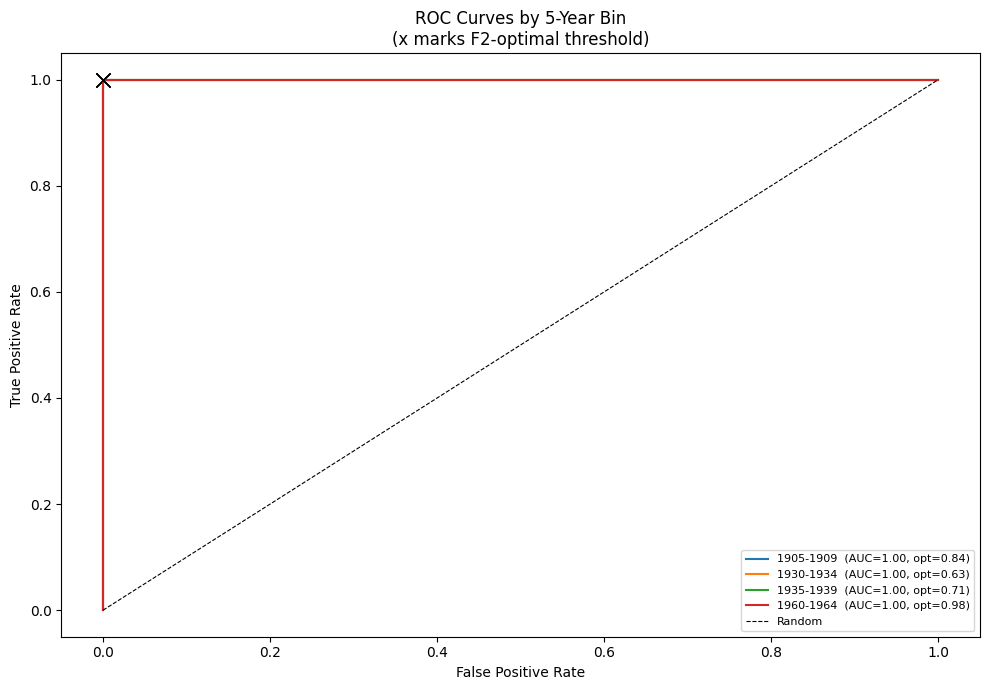


Optimal threshold per 5-year bin (F2-score, recall-weighted):
 year_bin  n_pages  auc  optimal_thresh  recall_at_opt  prec_at_opt
1905-1909        5  1.0           0.842            1.0          1.0
1930-1934        5  1.0           0.633            1.0          1.0
1935-1939        5  1.0           0.709            1.0          1.0
1960-1964        5  1.0           0.979            1.0          1.0

Recommended single threshold: 0.78 (median across bins)


In [10]:
from sklearn.metrics import roc_auc_score, roc_curve


def max_image_score(scores: list, classes: list) -> float:
    """Max confidence among image-class detections on this page."""
    img_scores = [s for s, c in zip(scores, classes) if c in IMAGE_CLASS_IDS]
    return float(max(img_scores)) if img_scores else 0.0


def max_class_score(scores: list, classes: list, class_id: int) -> float:
    """Max confidence for a specific class on this page."""
    cls_scores = [s for s, c in zip(scores, classes) if c == class_id]
    return float(max(cls_scores)) if cls_scores else 0.0


raw_df["max_image_score"] = raw_df.apply(
    lambda r: max_image_score(r["scores"], r["classes"]), axis=1)

for class_id, col in CLASS_COL_MAP.items():
    raw_df[f"max_{col}_score"] = raw_df.apply(
        lambda r, cid=class_id: max_class_score(r["scores"], r["classes"], cid), axis=1)

gt_cols = (["archive_path", "page_num", "has_image", "year"] +
           [f"has_{col}" for col in CLASS_COL_MAP.values()])
scored = raw_df.merge(val_df[gt_cols], on=["archive_path", "page_num"], how="inner")
scored["year"]     = scored["year"].astype(int)
scored["year_bin"] = (scored["year"] // 5) * 5

fig, ax = plt.subplots(figsize=(10, 7))
bin_optimal = []

for ybin, grp in scored.groupby("year_bin"):
    if grp["has_image"].nunique() < 2:
        print(f"  Skip {ybin}-{ybin+4}: only one class present")
        continue
    fpr, tpr, thresholds = roc_curve(grp["has_image"], grp["max_image_score"])
    auc_val = roc_auc_score(grp["has_image"], grp["max_image_score"])

    # F-beta (beta=2 weights recall twice over precision)
    beta = 2.0
    precision_arr = np.where(tpr + fpr > 0, tpr / (tpr + fpr + 1e-9), 0)
    fbeta = ((1 + beta**2) * precision_arr * tpr /
             (beta**2 * precision_arr + tpr + 1e-9))
    best_idx    = fbeta.argmax()
    best_thresh = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5

    bin_optimal.append({
        "year_bin":       f"{ybin}-{ybin+4}",
        "n_pages":        len(grp),
        "auc":            round(auc_val, 3),
        "optimal_thresh": round(best_thresh, 3),
        "recall_at_opt":  round(float(tpr[best_idx]), 3),
        "prec_at_opt":    round(float(precision_arr[best_idx]), 3),
    })

    ax.plot(fpr, tpr,
            label=f"{ybin}-{ybin+4}  (AUC={auc_val:.2f}, opt={best_thresh:.2f})")
    ax.plot(fpr[best_idx], tpr[best_idx], "x", markersize=10, color="black")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves by 5-Year Bin\n(x marks F2-optimal threshold)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_by_year_bin.png", dpi=150)
plt.show()

opt_df = pd.DataFrame(bin_optimal)
opt_df.to_csv(OUTPUT_DIR / "optimal_thresholds_by_year_bin.csv", index=False)
print("\nOptimal threshold per 5-year bin (F2-score, recall-weighted):")
print(opt_df.to_string(index=False))
print(f"\nRecommended single threshold: {opt_df['optimal_thresh'].median():.2f} (median across bins)")

### Does Per-Year Tuning Worsen Generalizability?

Inference (test): 83it [05:50,  4.23s/it]


Test-set comparison: fixed vs per-bin threshold
                         accuracy      f1  recall  precision
fixed (thresh=0.4)         0.9639  0.9691    0.94        1.0
per-bin (year-adaptive)    0.9157  0.9247    0.86        1.0

F1 delta (per-bin - fixed): -0.0443
  Positive = per-bin is better on unseen data.
  Negative = overfitting to val-set year patterns.

Per-class breakdown on test set (fixed threshold):
  photograph             -> TP= 44 FP=  0 TN= 36 FN=  3 | F1=0.967 Rec=0.936
  illustration           -> TP=  3 FP=  2 TN= 77 FN=  1 | F1=0.667 Rec=0.750
  map                    -> TP=  0 FP=  3 TN= 80 FN=  0 | F1=0.000 Rec=0.000
  comic                  -> TP=  1 FP=  1 TN= 80 FN=  1 | F1=0.500 Rec=0.500
  editorial_cartoon      -> TP=  0 FP=  0 TN= 79 FN=  4 | F1=0.000 Rec=0.000


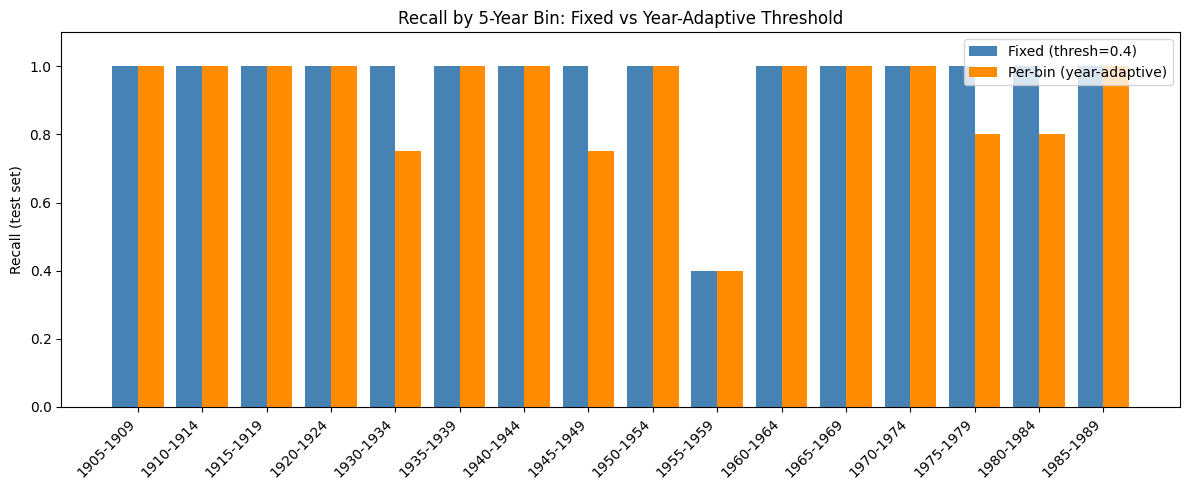


All outputs saved to /content/drive/MyDrive/gridsearch_results


In [11]:
# run inference on test set
test_grouped = test_df.groupby("archive_path")["page_num"].apply(list)
test_raw = []
for archive_path, pages in tqdm(test_grouped.items(), desc="Inference (test)"):
    test_raw.extend(infer_pdf_pages(archive_path, pages))

test_raw_df = pd.DataFrame(test_raw)
test_raw_df["max_image_score"] = test_raw_df.apply(
    lambda r: max_image_score(r["scores"], r["classes"]), axis=1)

for class_id, col in CLASS_COL_MAP.items():
    test_raw_df[f"max_{col}_score"] = test_raw_df.apply(
        lambda r, cid=class_id: max_class_score(r["scores"], r["classes"], cid), axis=1)

gt_cols = (["archive_path", "page_num", "has_image", "year"] +
           [f"has_{col}" for col in CLASS_COL_MAP.values()])
test_scored = test_raw_df.merge(test_df[gt_cols],
                                on=["archive_path", "page_num"], how="inner")
test_scored["year"]     = test_scored["year"].astype(int)
test_scored["year_bin"] = (test_scored["year"] // 5) * 5

bin_thresh_map = opt_df.set_index("year_bin")["optimal_thresh"].to_dict()
GLOBAL_THRESH  = float(opt_df["optimal_thresh"].median())

agg_metrics_indexed = (
    metrics_df[metrics_df["class"] == "aggregate"].set_index("threshold")
)
best_fixed = agg_metrics_indexed["f1"].idxmax()

def predict_with_map(row, thresh_map, fallback):
    thresh = thresh_map.get(row["year_bin"], fallback)
    return int(row["max_image_score"] >= thresh)

test_scored["pred_fixed"]  = (test_scored["max_image_score"] >= best_fixed).astype(int)
test_scored["pred_perbin"] = test_scored.apply(
    predict_with_map, thresh_map=bin_thresh_map, fallback=GLOBAL_THRESH, axis=1)

# aggregate comparison
comparison = {}
for strategy, col in [(f"fixed (thresh={best_fixed})", "pred_fixed"),
                      ("per-bin (year-adaptive)",       "pred_perbin")]:
    comparison[strategy] = {
        "accuracy":  accuracy_score(test_scored["has_image"], test_scored[col]),
        "f1":        f1_score(test_scored["has_image"], test_scored[col], zero_division=0),
        "recall":    recall_score(test_scored["has_image"], test_scored[col], zero_division=0),
        "precision": precision_score(test_scored["has_image"], test_scored[col], zero_division=0),
    }

comp_df = pd.DataFrame(comparison).T
comp_df.to_csv(OUTPUT_DIR / "generalizability_comparison.csv")
print("Test-set comparison: fixed vs per-bin threshold")
print(comp_df.round(4).to_string())

delta_f1 = (comp_df.loc["per-bin (year-adaptive)", "f1"] -
            comp_df.loc[f"fixed (thresh={best_fixed})", "f1"])
print(f"\nF1 delta (per-bin - fixed): {delta_f1:+.4f}")
print("  Positive = per-bin is better on unseen data.")
print("  Negative = overfitting to val-set year patterns.")

# per-class TP/FP/TN/FN on test set (fixed threshold)
print("\nPer-class breakdown on test set (fixed threshold):")
for class_id, col in CLASS_COL_MAP.items():
    pred_col = f"pred_fixed_{col}"
    test_scored[pred_col] = (test_scored[f"max_{col}_score"] >= best_fixed).astype(int)
    yt = test_scored[f"has_{col}"]
    yp = test_scored[pred_col]
    tp  = int(((yp == 1) & (yt == 1)).sum())
    fp  = int(((yp == 1) & (yt == 0)).sum())
    tn  = int(((yp == 0) & (yt == 0)).sum())
    fn  = int(((yp == 0) & (yt == 1)).sum())
    f1  = f1_score(yt, yp, zero_division=0)
    rec = recall_score(yt, yp, zero_division=0)
    print(f"  {col:22s} -> TP={tp:3d} FP={fp:3d} TN={tn:3d} FN={fn:3d} | F1={f1:.3f} Rec={rec:.3f}")

# recall by year bin: fixed vs adaptive
bin_recalls = []
for ybin, grp in test_scored.groupby("year_bin"):
    if grp["has_image"].sum() == 0:
        continue
    bin_recalls.append({
        "year_bin":      f"{ybin}-{ybin+4}",
        "recall_fixed":  recall_score(grp["has_image"], grp["pred_fixed"],  zero_division=0),
        "recall_perbin": recall_score(grp["has_image"], grp["pred_perbin"], zero_division=0),
    })

br_df = pd.DataFrame(bin_recalls)
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(br_df))
ax.bar([i - 0.2 for i in x], br_df["recall_fixed"],  width=0.4,
       label=f"Fixed (thresh={best_fixed})", color="steelblue")
ax.bar([i + 0.2 for i in x], br_df["recall_perbin"], width=0.4,
       label="Per-bin (year-adaptive)",  color="darkorange")
ax.set_xticks(list(x))
ax.set_xticklabels(br_df["year_bin"], rotation=45, ha="right")
ax.set_ylabel("Recall (test set)")
ax.set_title("Recall by 5-Year Bin: Fixed vs Year-Adaptive Threshold")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "recall_by_bin_fixed_vs_adaptive.png", dpi=150)
plt.show()

print(f"\nAll outputs saved to {OUTPUT_DIR}")